## Library

In [1]:
! pip install sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.2 MB/s eta 0:00:00


In [18]:
import pandas as pd
import re
import nltk
import numpy as np
import seaborn as sns
import joblib
import streamlit as st
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tqdm import tqdm
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from imblearn.over_sampling import RandomOverSampler

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Load Dataset Hasil Scraping

In [3]:
path = '/content/Brawl_Stars.csv'
df = pd.read_csv(path)
text_column = df.columns[0]
print("Kolom teks yang digunakan:", text_column)
print("Dataset shape", df.shape)
df.head()

Kolom teks yang digunakan: review
Dataset shape (9000, 1)


,review
0,Matchmaking game ini itu betul-betul jelek ban...
1,Keluh kesah main game ini selalu aja bertambah...
2,bagus tapi kadang suka lama (loading) kalau ud...
3,Game ini tolong kasih fitur chat lahhh biar bi...
4,gamenya bagus tapi pas mau buka karakter kenap...


## Preprocessing

In [5]:
stop_words = set(stopwords.words('indonesian'))
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def preprocess(text):
    cleaned = clean_text(text)
    tokens = cleaned.split()
    filtered = [w for w in tokens if w not in stop_words and len(w) > 2]
    stemmed = [stemmer.stem(w) for w in filtered]
    return " ".join(stemmed)

tqdm.pandas()

df['cleaned'] = df[text_column].progress_apply(preprocess)


100%|██████████| 9000/9000 [19:28<00:00,  7.70it/s]


In [6]:
df["cleaned"] = df[text_column].apply(clean_text)
positif = ["bagus","keren","mantap","seru","hebat","menarik","suka","asyik","baik","menyenangkan","Luarbiasa","hoki","ya"]
negatif = ["buruk","jelek","tidak","lemot","lag","payah","bosan","gagal","Parah","mengecewakan","sampah","paytowin","ampas"]

def label_sentimen(teks):
    t = teks.lower()
    pos = sum(t.count(p) for p in positif)
    neg = sum(t.count(n) for n in negatif)
    if pos > neg:
        return "positive"
    elif neg > pos:
        return "negative"
    else:
        return "neutral"

df["label"] = df["cleaned"].apply(label_sentimen)
print("\nDistribusi Label:")
print(df["label"].value_counts())


Distribusi Label:
label
positive    8255
neutral      461
negative     284
Name: count, dtype: int64


## Visualisasi Distribusi Sentimen

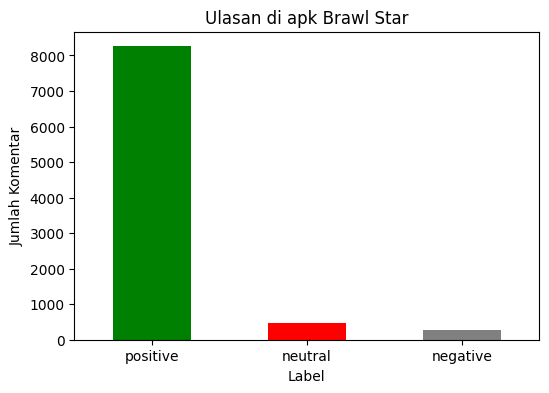

In [7]:
plt.figure(figsize=(6,4))
df['label'].value_counts().plot(kind='bar', color=['green','red','gray'])
plt.title("Ulasan di apk Brawl Star")
plt.xlabel("Label")
plt.ylabel("Jumlah Komentar")
plt.xticks(rotation=0)
plt.show()

## Word Cloud

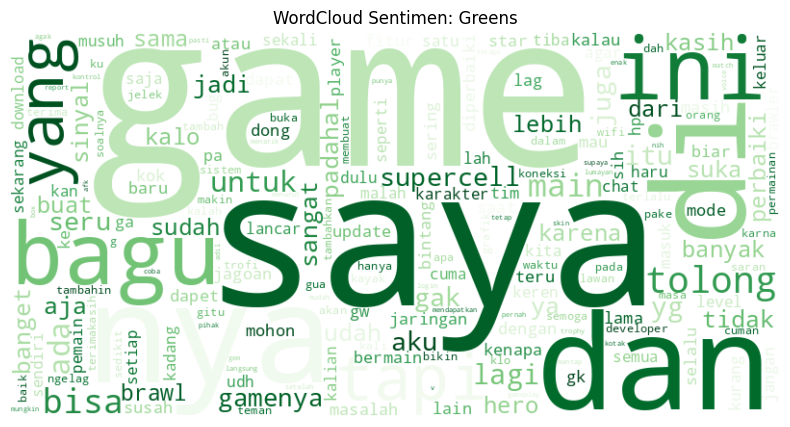

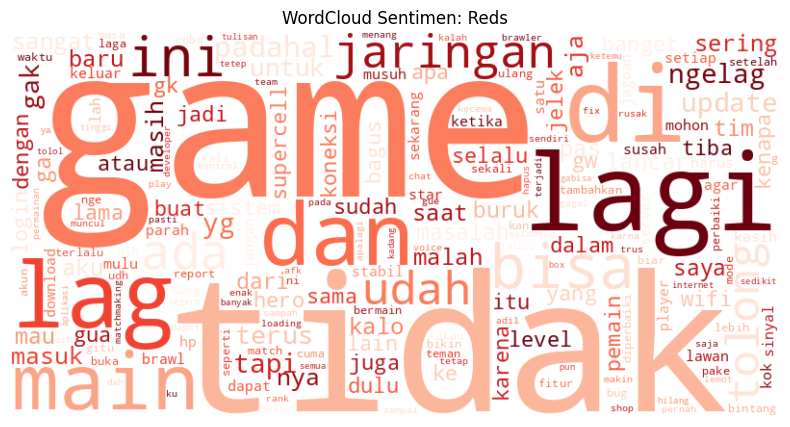

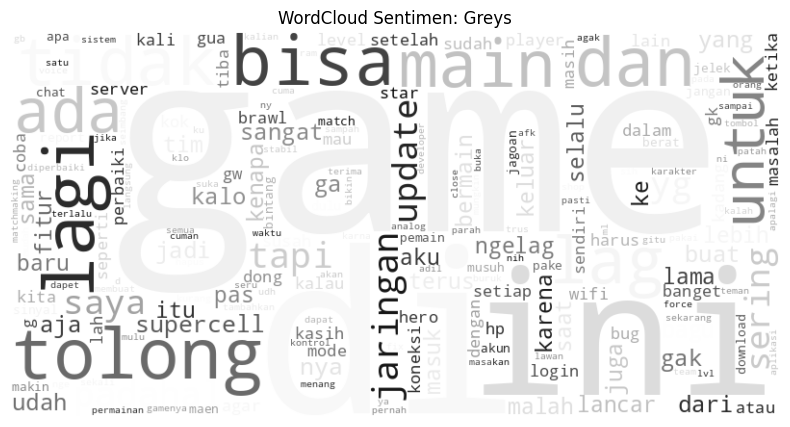

In [8]:
def buat_wordcloud(data, label_color):
    text = " ".join(data)
    wc = WordCloud(width=800, height=400, background_color="white",
                   colormap=label_color, collocations=False).generate(text)
    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"WordCloud Sentimen: {label_color.capitalize()}")
    plt.show()
for label, color in zip(["positive","negative","neutral"],
                        ["Greens","Reds","Greys"]):
    subset = df[df['label']==label]['cleaned']
    if not subset.empty:
        buat_wordcloud(subset, color)

Ekstrasi Firut TF-DF

In [9]:
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1,2), min_df=2, max_df=0.8)
X = tfidf.fit_transform(df['cleaned'])
y = df['label']


## Split data dan training

In [10]:
ros = RandomOverSampler(random_state=42)
X, y = ros.fit_resample(X, y)
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42, stratify=y)

## Model 1 - Logistik Regression

In [11]:
model1 = LogisticRegression(max_iter=500)
model1.fit(x_train, y_train)
pred1 = model1.predict(x_test)
acc1 = accuracy_score(y_test, pred1)
print(f"\n Logistic Regression Acc: {acc1*100:.2f}%")


 Logistic Regression Acc: 97.50%


## Model 2 - Random Forest

In [12]:
model2 = RandomForestClassifier(n_estimators=200, random_state=42)
model2.fit(x_train, y_train)
pred2 = model2.predict(x_test)
acc2 = accuracy_score(y_test, pred2)
print(f" Random Forest Acc: {acc2*100:.2f}%")

 Random Forest Acc: 99.84%


## Model 3 - support vector Machine

In [13]:
model3 = SVC(kernel='linear', C=1)
model3.fit(x_train, y_train)
pred3 = model3.predict(x_test)
acc3 = accuracy_score(y_test, pred3)
print(f" SVM Acc: {acc3*100:.2f}%")

 SVM Acc: 98.41%


## Evaluasi Keseluruhan

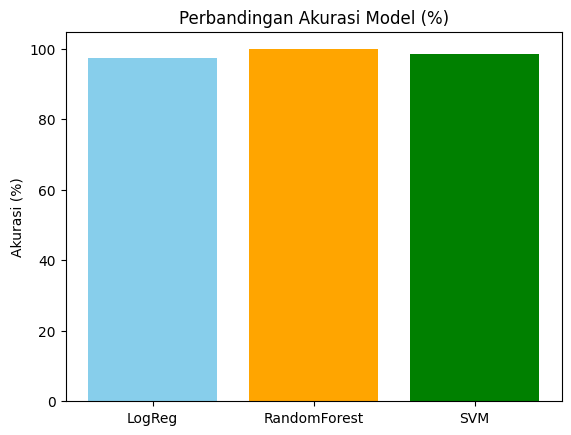


 Model terbaik: RandomForest dengan akurasi 99.84%


In [14]:
models = {"LogReg": acc1, "RandomForest": acc2, "SVM": acc3}
plt.bar(models.keys(), [v*100 for v in models.values()], color=['skyblue','orange','green'])
plt.title("Perbandingan Akurasi Model (%)")
plt.ylabel("Akurasi (%)")
plt.show()

best_model = max(models, key=models.get)
print(f"\n Model terbaik: {best_model} dengan akurasi {models[best_model]*100:.2f}%")

model 1 Logregresion
model 2 Random forest
model 3 SVM



In [16]:
joblib.dump(model1, 'model1.pkl')
joblib.dump(model2, 'model2.pkl')
joblib.dump(model3, 'model3.pkl')
joblib.dump(tfidf, 'tfidf.pkl')

['tfidf.pkl']

In [19]:
model = joblib.load('model1.pkl')

st.title("Aplikasi Sentiment Analysis")

text = st.text_input("Masukkan teks untuk analisis sentimen:")

if st.button("Analisis Sentimen"):
    result = model.predict([text])[0]
    st.write(f"Hasil analisis sentimen: {result}")

2025-10-18 04:39:50.294 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-18 04:39:50.295 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-18 04:39:50.297 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-18 04:39:50.299 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-18 04:39:50.301 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-18 04:39:50.302 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-18 04:39:50.304 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-18 04:39:50.305 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

## Cara buat requirements.txt

In [20]:
pip freeze > requirements.txt